# 04 - Waller-Lab DiffuserCam Tutorial Sample Data

In the first three notebooks, we controlled the scene, PSF, and noise in simulation. Now we test our implementation on the sample measured data from the Waller-Lab DiffuserCam tutorial.

The two key files are:

- `psf_sample.tif`: measured point spread function calibration image
- `rawdata_hand_sample.tif`: measured lensless sensor image of a hand

Unlike our simulations, this real sample has no exact ground-truth image. That means we should not compute PSNR or SSIM. Instead, we look at preprocessing, convergence, residuals, and whether the reconstruction is visually plausible.

## Setup

This notebook uses the reusable code in `src/diffusercam_sim`. It also searches for the Waller data in either of these layouts:

```text
data/external/tutorial/psf_sample.tif
data/external/tutorial/rawdata_hand_sample.tif
```

or:

```text
data/external/waller_lab_diffusercam_tutorial/tutorial/psf_sample.tif
data/external/waller_lab_diffusercam_tutorial/tutorial/rawdata_hand_sample.tif
```

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import (
    PaddedLinearConvolution,
    center_support_mask,
    find_waller_tutorial_paths,
    fista,
    preprocess_waller_tutorial_sample,
    residual_relative_l2,
)
from diffusercam_sim.viz import save_montage, save_objective_residual_plot

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '04_waller_lab_sample_data'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

## Locate and Inspect the Raw TIFF Files

The tutorial data are 16-bit TIFF files. The raw image dimensions are larger than we want for a first interactive reconstruction, so we will downsample exactly as the Waller tutorial does.

In [2]:
psf_path, rawdata_path = find_waller_tutorial_paths(PROJECT_ROOT)

raw_psf_image = Image.open(psf_path)
raw_measurement_image = Image.open(rawdata_path)

raw_file_info = {
    'psf_path': str(psf_path),
    'rawdata_path': str(rawdata_path),
    'psf_mode': raw_psf_image.mode,
    'rawdata_mode': raw_measurement_image.mode,
    'psf_size_width_height': raw_psf_image.size,
    'rawdata_size_width_height': raw_measurement_image.size,
    'psf_extrema': raw_psf_image.getextrema(),
    'rawdata_extrema': raw_measurement_image.getextrema(),
}

raw_file_info

{'psf_path': 'E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\psf_sample.tif',
 'rawdata_path': 'E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\rawdata_hand_sample.tif',
 'psf_mode': 'I;16',
 'rawdata_mode': 'I;16',
 'psf_size_width_height': (1600, 1200),
 'rawdata_size_width_height': (1600, 1200),
 'psf_extrema': (0, 65520),
 'rawdata_extrema': (144, 37184)}

## Preprocessing: Match the Tutorial Convention

The Waller tutorial preprocessing is deliberately simple:

1. Load the PSF and raw sensor image.
2. Estimate the camera background from `psf[5:15, 5:15]`.
3. Subtract that same background from both images.
4. Downsample by repeated `2 x 2` averaging. This acts like a simple demosaicing/downsampling filter.
5. Normalize PSF and measurement to unit L2 norm.

That final normalization is not physics by itself. It is a numerical convention: it makes step sizes and regularization parameters more predictable.

In [3]:
downsample_factor = 1 / 8
sample = preprocess_waller_tutorial_sample(
    psf_path=psf_path,
    measurement_path=rawdata_path,
    downsample_factor=downsample_factor,
)

preprocess_info = {
    'background_estimate': sample.background,
    'downsample_factor': sample.downsample_factor,
    'raw_shape_rows_cols': sample.psf_raw.shape,
    'processed_shape_rows_cols': sample.psf.shape,
    'psf_l2_norm': float(np.linalg.norm(sample.psf.ravel())),
    'measurement_l2_norm': float(np.linalg.norm(sample.measurement.ravel())),
    'psf_min_max': (float(sample.psf.min()), float(sample.psf.max())),
    'measurement_min_max': (float(sample.measurement.min()), float(sample.measurement.max())),
}

preprocess_info

{'background_estimate': 34.08,
 'downsample_factor': 0.125,
 'raw_shape_rows_cols': (1200, 1600),
 'processed_shape_rows_cols': (150, 200),
 'psf_l2_norm': 0.9999999999999998,
 'measurement_l2_norm': 1.0,
 'psf_min_max': (-2.0508879285147105e-05, 0.07417686661659734),
 'measurement_min_max': (5.266037475104298e-05, 0.01067266381844944)}

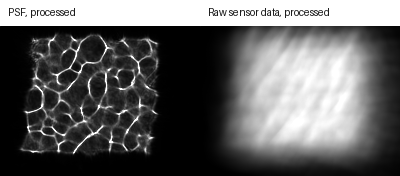

In [4]:
save_montage(
    [
        ('PSF, processed', sample.psf),
        ('Raw sensor data, processed', sample.measurement),
    ],
    RESULT_DIR / 'processed_inputs.png',
    columns=2,
)
Image.open(RESULT_DIR / 'processed_inputs.png')

## Build the Padded Linear Convolution Operator

We now treat the measured PSF as the calibration image for our forward model:

$$ b \approx A x $$

where `A` means:

```text
pad scene estimate -> FFT convolution with measured PSF -> crop to sensor size
```

Before reconstructing, we verify the adjoint relation:

$$ \langle Ax, y \rangle = \langle x, A^H y \rangle $$

This check is especially important with non-square real data.

In [5]:
operator = PaddedLinearConvolution(sample.psf)
support_mask = center_support_mask(operator)

operator_info = {
    'image_shape': operator.image_shape,
    'padded_shape': operator.padded_shape,
    'lipschitz_bound': operator.lipschitz_bound,
    'default_step_size_without_l2': 1.8 / operator.lipschitz_bound,
    'adjoint_inner_product_error': operator.adjoint_inner_product_error(),
}

operator_info

{'image_shape': (150, 200),
 'padded_shape': (512, 512),
 'lipschitz_bound': 7478.769073266526,
 'default_step_size_without_l2': 0.00024068131832472912,
 'adjoint_inner_product_error': 2.056579521084895e-15}

## Reconstruction Experiments

We compare four FISTA variants:

1. **Baseline**: nonnegativity only, matching the basic tutorial spirit.
2. **Support**: nonnegativity plus zero outside the center crop.
3. **L2**: nonnegativity plus an energy penalty.
4. **Support + L2**: both priors together.

Because there is no ground truth, the final residual is not a complete quality metric. A lower residual means the forward model matches the measurement better, but it can still overfit noise or calibration mismatch.

In [6]:
iterations = 250
record_every = 5
l2_lambda = 1e-2

experiments = [
    {'name': 'baseline', 'title': 'Baseline', 'support_mask': None, 'l2_regularization': 0.0},
    {'name': 'support', 'title': 'Support', 'support_mask': support_mask, 'l2_regularization': 0.0},
    {'name': 'l2', 'title': 'L2', 'support_mask': None, 'l2_regularization': l2_lambda},
    {'name': 'support_l2', 'title': 'Support + L2', 'support_mask': support_mask, 'l2_regularization': l2_lambda},
]

results = {}
for experiment in experiments:
    results[experiment['name']] = fista(
        operator=operator,
        measurement=sample.measurement,
        iterations=iterations,
        record_every=record_every,
        support_mask=experiment['support_mask'],
        l2_regularization=experiment['l2_regularization'],
    )

[(name, result.history[-1]) for name, result in results.items()]

[('baseline',
  IterationRecord(iteration=250, objective=1.2526402664904676e-05, relative_residual_l2=0.005005277747519048, psnr_db=None, ssim=None)),
 ('support',
  IterationRecord(iteration=250, objective=1.9964254156095282e-05, relative_residual_l2=0.006318900878490703, psnr_db=None, ssim=None)),
 ('l2',
  IterationRecord(iteration=250, objective=1.8889667323217567e-05, relative_residual_l2=0.005006304397060345, psnr_db=None, ssim=None)),
 ('support_l2',
  IterationRecord(iteration=250, objective=2.622469103004987e-05, relative_residual_l2=0.00632003904680252, psnr_db=None, ssim=None))]

## Quantitative Diagnostics Without Ground Truth

Here we report objective and relative residual:

$$ \frac{\|Ax-b\|_2}{\|b\|_2} $$

This tells us how well the reconstruction explains the measured raw sensor image under our calibrated forward model.

In [7]:
summary = {
    'raw_files': raw_file_info,
    'preprocessing': preprocess_info,
    'operator': operator_info,
    'experiments': {},
}

for experiment in experiments:
    name = experiment['name']
    result = results[name]
    predicted = operator.forward_padded(result.padded_estimate)
    summary['experiments'][name] = {
        'uses_support_constraint': experiment['support_mask'] is not None,
        'l2_regularization': experiment['l2_regularization'],
        'step_size': result.step_size,
        'final_objective': result.history[-1].objective,
        'final_relative_residual_l2': residual_relative_l2(sample.measurement, predicted),
        'reconstruction_min_max': (
            float(result.reconstruction.min()),
            float(result.reconstruction.max()),
        ),
    }

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary['experiments'], indent=2))

{
  "baseline": {
    "uses_support_constraint": false,
    "l2_regularization": 0.0,
    "step_size": 0.00024068131832472912,
    "final_objective": 1.2526402664904676e-05,
    "final_relative_residual_l2": 0.005005277747519048,
    "reconstruction_min_max": [
      0.0,
      0.00244115142636182
    ]
  },
  "support": {
    "uses_support_constraint": true,
    "l2_regularization": 0.0,
    "step_size": 0.00024068131832472912,
    "final_objective": 1.9964254156095282e-05,
    "final_relative_residual_l2": 0.006318900878490703,
    "reconstruction_min_max": [
      0.0,
      0.0024164874160863053
    ]
  },
  "l2": {
    "uses_support_constraint": false,
    "l2_regularization": 0.01,
    "step_size": 0.0002406809965057317,
    "final_objective": 1.8889667323217567e-05,
    "final_relative_residual_l2": 0.005006304397060345,
    "reconstruction_min_max": [
      0.0,
      0.0024352952113357784
    ]
  },
  "support_l2": {
    "uses_support_constraint": true,
    "l2_regularization"

## Visual Reconstruction Comparison

The hand may appear mirrored or rotated relative to intuition depending on the measurement geometry and display convention. At this stage, we care most about whether a coherent hand-like object emerges from the raw caustic measurement.

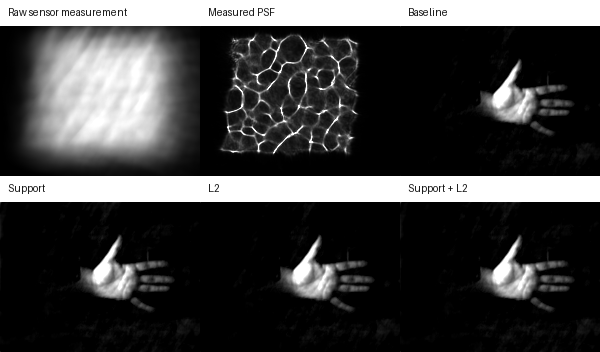

In [8]:
save_montage(
    [
        ('Raw sensor measurement', sample.measurement),
        ('Measured PSF', sample.psf),
        ('Baseline', results['baseline'].reconstruction),
        ('Support', results['support'].reconstruction),
        ('L2', results['l2'].reconstruction),
        ('Support + L2', results['support_l2'].reconstruction),
    ],
    RESULT_DIR / 'reconstruction_comparison.png',
    columns=3,
)
Image.open(RESULT_DIR / 'reconstruction_comparison.png')

## Objective and Residual Convergence

Because we lack ground truth, convergence plots should show objective and relative residual instead of PSNR.

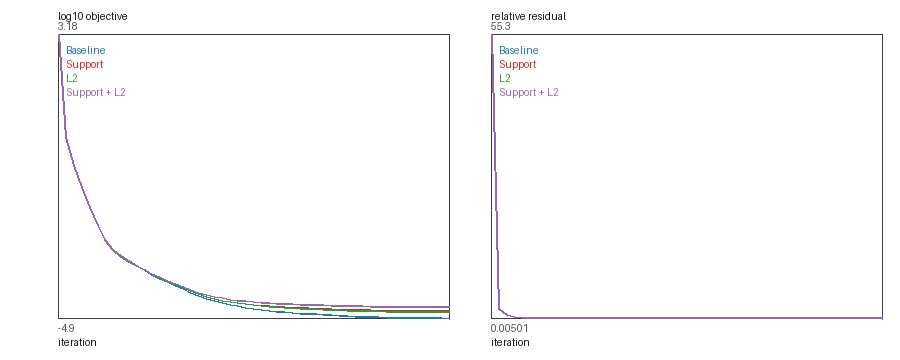

In [9]:
save_objective_residual_plot(
    [(experiment['title'], results[experiment['name']].history) for experiment in experiments],
    RESULT_DIR / 'objective_residual_convergence.png',
)
Image.open(RESULT_DIR / 'objective_residual_convergence.png')

## Test Images Folder

The `test_images` folder contains images intended to be displayed on a phone or laptop screen when capturing new hardware data. These are not ground truth for `rawdata_hand_sample.tif`, but they are useful later when we build our own camera.

In [10]:
test_image_dir = PROJECT_ROOT / 'data' / 'external' / 'test_images'
test_images = sorted(path.name for path in test_image_dir.glob('*') if path.is_file())
test_images

['cal_logo_rgb.png',
 'dog_rgb.jpg',
 'google_chrome_logo_rgb.png',
 'spiral_bw.gif']

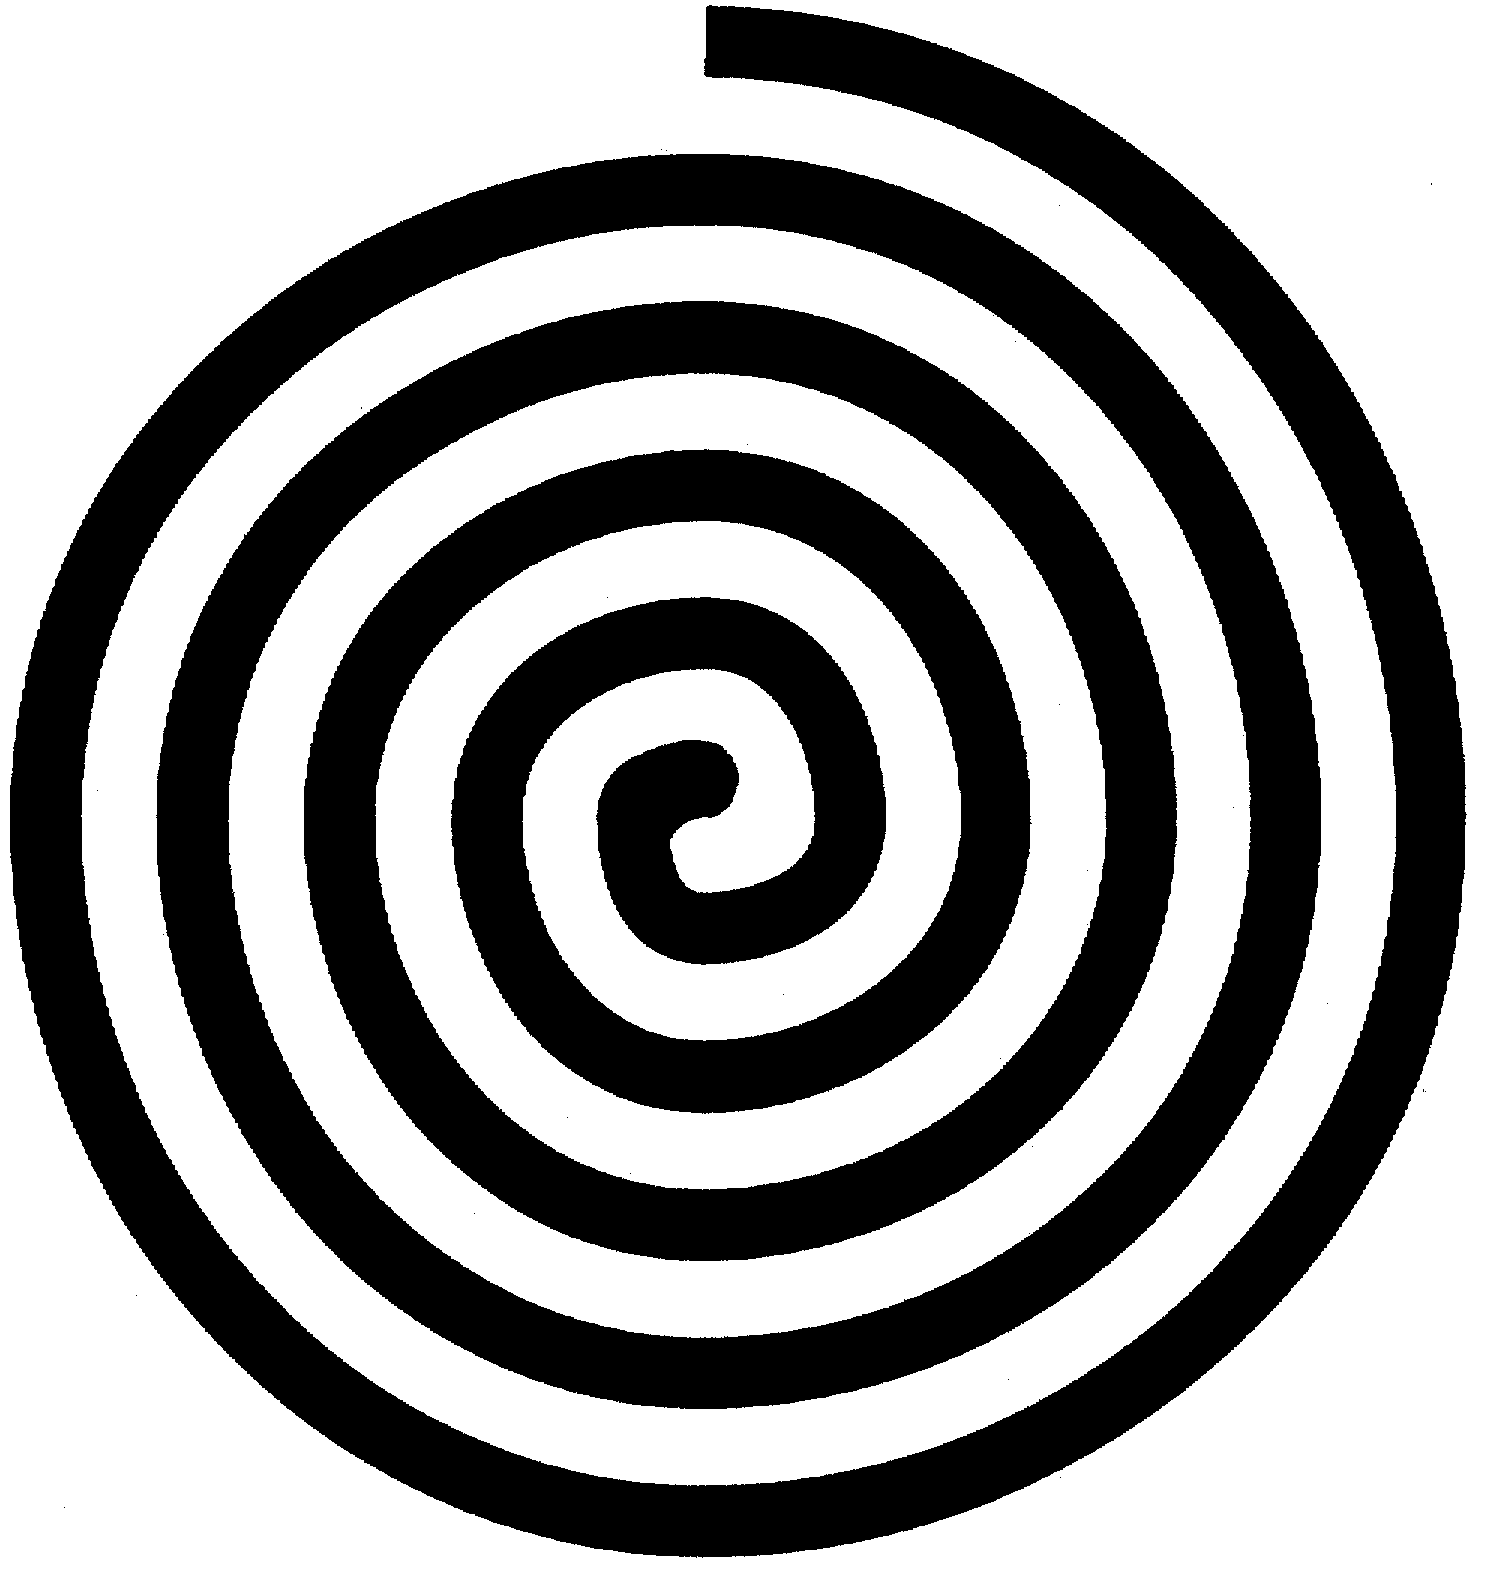

In [11]:
spiral_path = test_image_dir / 'spiral_bw.gif'
if spiral_path.exists():
    display_spiral = Image.open(spiral_path)
else:
    display_spiral = None

display_spiral

## What We Learned

- Our implementation can ingest the Waller tutorial's real measured PSF/raw-data pair.
- The preprocessing choices matter: background subtraction, downsampling, and normalization change the numerical scale of the inverse problem.
- For real data, residual is useful but incomplete. Without ground truth, we need visual checks and later calibration experiments.
- The next natural step is to tune preprocessing and reconstruction parameters against the Waller tutorial output more carefully, then add TV/ADMM.